# CASALS L1B Beam Geometry and Bin Georeference Theory

This notebook records the current understanding of CASALS L1B georeferencing for waveform data. It is designed as a **research audit notebook**, not as a production geolocation script.

Main objectives:

1. Inspect the H5 file structure, with emphasis on geolocation, height, beam-angle, range-window, and waveform variables.
2. Record the beam-geometry theory behind refh geolocation and possible all-bin georeferencing.
3. Reproduce the current internal consistency checks: instrument height, refh, beam angles, rwstart/rwstop, and bin_size.
4. Visualize one sweep in a real metric 3D coordinate system with Plotly.
5. Clearly separate established findings, likely interpretations, and unresolved assumptions.

External reference used for variable interpretation: the CryoCloud CASALS L1B tutorial. It lists variables such as `instrument_altitude`, `local_beam_azimuth`, `local_beam_elevation`, `rwstart`, `rwstop`, `bin_size`, `rx_waveform`, and `refh`, and describes `refh` as the geolocated reference height of the maximum-amplitude RX waveform bin.

**Boundary statement.**  
This notebook validates the **internal beam-line geometry** of official CASALS `refh` points. It does not by itself prove the external vertical datum of all height variables, nor does it finalize production-grade geolocation for every RX waveform bin.

## 0. Conceptual summary

For pulse / track $i$, define the H5 instrument position and the official reference-height point as:

$$
\mathbf{I}_i=(X_i,Y_i,Z_i),
\qquad
\mathbf{P}_i=(x_i,y_i,z_i).
$$

The current physically consistent convention for the tested sweep is:

$$
\text{radian}
+
\text{north-clockwise azimuth}
+
\text{elevation-from-horizon}
+
\text{negated direction}
+
\text{instrument anchor}.
$$

In projected East-North-Up coordinates, the canonical no-bias beam unit vector is:

$$
\mathbf{u}_i =
-
\begin{bmatrix}
\cos(e_i)\sin(a_i) \\
\cos(e_i)\cos(a_i) \\
\sin(e_i)
\end{bmatrix}.
$$

The beam ray is:

$$
\mathbf{X}_i(r)=\mathbf{I}_i+r\mathbf{u}_i,\qquad r>0.
$$

A small empirical azimuth correction,

$$
a_i^*=a_i+\Delta a,
$$

was found to improve one-sweep closure, with $\Delta a \approx +0.10^\circ$. This is treated as a **calibration hypothesis**, not as an official field definition.

## 1. Configuration

The default paths assume this notebook is placed under `CASALS_L1B/notebooks/`.

In [47]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Any, Dict, Optional, Sequence, Tuple

import h5py
import numpy as np
import pandas as pd
from pyproj import CRS, Transformer

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import plotly.graph_objects as go

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

H5_PATH = Path("../casals_h5_downloads/casals_l1b_20241112T165718_001_02.h5")
SWEEP_INDEX = 7040

AUDIT_ROOT = Path("../beam_line_origin")
AUDIT_SCORES_DIR = AUDIT_ROOT / "scores"
HEIGHT_SANITY_JSON = AUDIT_SCORES_DIR / f"sw_{SWEEP_INDEX}_h5_height_sanity.json"
COMPACT_SCORES_CSV = AUDIT_SCORES_DIR / f"sw_{SWEEP_INDEX}_origin_scores_compact.csv"
RECOMMENDED_RULES_CSV = AUDIT_SCORES_DIR / f"sw_{SWEEP_INDEX}_recommended_physical_rules.csv"
PER_TRACK_DIAGNOSTICS_CSV = AUDIT_SCORES_DIR / f"sw_{SWEEP_INDEX}_top_rule_per_track_diagnostics.csv"

EXPECTED_AGL_BANDS_M = [(3500.0, 6500.0), (7500.0, 9500.0)]

# Use the no-bias canonical rule for the main interpretation.
# Use +0.10 deg only as a sensitivity / calibration comparison.
AZ_BIAS_DEG = 0.10
EL_BIAS_DEG = 0.0
USE_AZ_BIAS_REFINEMENT_FOR_VISUALIZATION = False

MAX_RAYS_TO_DRAW = 256
DRAW_RWSTART_RWSTOP = True
ADAPTIVE_AXIS_MIN_RATIO = 0.55

PLOTLY_3D_COLORS = {
    "refh": "#00A6FB",
    "instrument": "#0F172A",
    "median_instrument": "#F43F5E",
    "rays": "rgba(37, 99, 235, 0.82)",
    "rwstart": "#C026D3",
    "rwstop": "#F59E0B",
    "background": "#F8FAFC",
    "grid": "#CBD5E1",
    "zero": "#94A3B8",
}

print("H5_PATH:", H5_PATH)
print("SWEEP_INDEX:", SWEEP_INDEX)
print("Audit score directory:", AUDIT_SCORES_DIR)

H5_PATH: ..\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5
SWEEP_INDEX: 7040
Audit score directory: ..\beam_line_origin\scores


## 2. H5 variables relevant to georeferencing

The H5 fields are grouped conceptually as follows.

**Pulse organization**

- `sweep_num`: sweep index.
- `track_num`: track/channel index.
- `delta_time`: pulse time coordinate.

**Official refh point**

- `refh_longitude`
- `refh_latitude`
- `refh`
- `refh_amp`
- `refh_snr`
- `refh_error`

The `refh` point is one official geolocated point per pulse. It is not a full geolocation of every RX waveform bin.

**Instrument / sensor position**

- `instrument_longitude`
- `instrument_latitude`
- `instrument_altitude`
- `instrument_altitude_error`

These fields are used here as H5-internal platform position fields. Their external vertical datum still requires independent confirmation.

**Beam angles**

- `local_beam_azimuth`
- `local_beam_elevation`
- associated error fields

The current central problem is interpreting these angular fields as an East-North-Up unit vector.

**Range-window geometry**

- `rwstart_longitude`, `rwstart_latitude`, `rwstart`
- `rwstop_longitude`, `rwstop_latitude`, `rwstop`
- `bin_size`

These fields provide the main evidence for mapping RX bins onto the validated beam ray.

**Waveforms**

- `rx_waveform`
- `tx_waveform`
- `rx_bins`
- `tx_bins`

### Fields not used in this notebook but relevant for production geolocation

The notebook now also inspects correction, timing, tide, and illumination fields such as `range_bias_correction`, bounce-time offsets, neutral-atmosphere delay terms, tide terms, `dac`, and solar angles.

These fields are not used here for beam-line closure. They may be relevant to production-level range or height correction, but this notebook does not claim to have fully resolved their operational role.


In [48]:
DATASET_CANDIDATES: Dict[str, Sequence[str]] = {
    "sweep_num": ("sweep_num", "sweep", "sweep_index"),
    "track_num": ("track_num", "track", "track_index"),
    "delta_time": ("delta_time", "time"),

    "refh_lon": ("refh_longitude", "longitude", "lon"),
    "refh_lat": ("refh_latitude", "latitude", "lat"),
    "refh_z": ("refh", "refh_height", "height", "elevation"),
    "refh_error": ("refh_error",),
    "refh_amp": ("refh_amp",),
    "refh_snr": ("refh_snr",),
    "refh_thres": ("refh_thres",),

    "instrument_lon": ("instrument_longitude", "sensor_longitude", "platform_longitude"),
    "instrument_lat": ("instrument_latitude", "sensor_latitude", "platform_latitude"),
    "instrument_z": ("instrument_altitude", "instrument_height", "sensor_altitude", "platform_altitude"),
    "instrument_z_error": ("instrument_altitude_error",),

    "beam_az": ("local_beam_azimuth", "beam_azimuth", "azimuth"),
    "beam_el": ("local_beam_elevation", "beam_elevation", "elevation"),
    "beam_az_error": ("local_beam_azimuth_error",),
    "beam_el_error": ("local_beam_elevation_error",),

    "rwstart_lon": ("rwstart_longitude",),
    "rwstart_lat": ("rwstart_latitude",),
    "rwstart_z": ("rwstart",),
    "rwstop_lon": ("rwstop_longitude",),
    "rwstop_lat": ("rwstop_latitude",),
    "rwstop_z": ("rwstop",),

    "bin_size": ("bin_size",),
    "geoid": ("geoid",),
    "geoid_free2mean": ("geoid_free2mean",),
    "bg_mean": ("bg_mean",),
    "bg_std": ("bg_std",),
    "range_bias_correction": ("range_bias_correction",),

    "refh_bounce_time_offset": ("refh_bounce_time_offset",),
    "refh_bounce_time_offset_error": ("refh_bounce_time_offset_error",),
    "refh_neutat_delay_total": ("refh_neutat_delay_total",),
    "refh_neutat_delay_derivative": ("refh_neutat_delay_derivative",),

    "rwstart_bounce_time_offset": ("rwstart_bounce_time_offset",),
    "rwstart_bounce_time_offset_error": ("rwstart_bounce_time_offset_error",),
    "rwstart_neutat_delay_total": ("rwstart_neutat_delay_total",),
    "rwstart_neutat_delay_derivative": ("rwstart_neutat_delay_derivative",),

    "rwstop_bounce_time_offset": ("rwstop_bounce_time_offset",),
    "rwstop_bounce_time_offset_error": ("rwstop_bounce_time_offset_error",),
    "rwstop_neutat_delay_total": ("rwstop_neutat_delay_total",),
    "rwstop_neutat_delay_derivative": ("rwstop_neutat_delay_derivative",),

    "tide_earth": ("tide_earth",),
    "tide_earth_free2mean": ("tide_earth_free2mean",),
    "tide_load": ("tide_load",),
    "tide_ocean": ("tide_ocean",),
    "tide_ocean_pole": ("tide_ocean_pole",),
    "tide_pole": ("tide_pole",),

    "dac": ("dac",),
    "solar_azimuth": ("solar_azimuth",),
    "solar_elevation": ("solar_elevation",),

    "rx_waveform": ("rx_waveform",),
    "tx_waveform": ("tx_waveform",),
    "rx_bins": ("rx_bins",),
    "tx_bins": ("tx_bins",),
}

FIELD_GROUPS = {
    "organization": ["sweep_num", "track_num", "delta_time"],
    "official_refh_point": ["refh_lon", "refh_lat", "refh_z", "refh_error", "refh_amp", "refh_snr", "refh_thres"],
    "instrument_position": ["instrument_lon", "instrument_lat", "instrument_z", "instrument_z_error"],
    "beam_angles": ["beam_az", "beam_el", "beam_az_error", "beam_el_error"],
    "range_window": ["rwstart_lon", "rwstart_lat", "rwstart_z", "rwstop_lon", "rwstop_lat", "rwstop_z", "bin_size"],
    "vertical_corrections": ["geoid", "geoid_free2mean"],
    "waveform_background": ["bg_mean", "bg_std", "rx_waveform", "tx_waveform", "rx_bins", "tx_bins"],
    "production_geolocation_corrections": [
        "range_bias_correction",
        "refh_bounce_time_offset", "refh_bounce_time_offset_error", "refh_neutat_delay_total", "refh_neutat_delay_derivative",
        "rwstart_bounce_time_offset", "rwstart_bounce_time_offset_error", "rwstart_neutat_delay_total", "rwstart_neutat_delay_derivative",
        "rwstop_bounce_time_offset", "rwstop_bounce_time_offset_error", "rwstop_neutat_delay_total", "rwstop_neutat_delay_derivative",
        "tide_earth", "tide_earth_free2mean", "tide_load", "tide_ocean", "tide_ocean_pole", "tide_pole",
        "dac", "solar_azimuth", "solar_elevation",
    ],
}

NUMERIC_SUMMARY_SPECS: list[tuple[str, str]] = [
    ("refh", "refh_z"),
    ("refh_error", "refh_error"),
    ("refh_amp", "refh_amp"),
    ("refh_snr", "refh_snr"),
    ("instrument_altitude", "instrument_z"),
    ("instrument_altitude_error", "instrument_z_error"),
    ("local_beam_azimuth", "beam_az"),
    ("local_beam_elevation", "beam_el"),
    ("local_beam_azimuth_error", "beam_az_error"),
    ("local_beam_elevation_error", "beam_el_error"),
    ("rwstart", "rwstart_z"),
    ("rwstop", "rwstop_z"),
    ("bin_size", "bin_size"),
    ("geoid", "geoid"),
    ("geoid_free2mean", "geoid_free2mean"),
    ("bg_mean", "bg_mean"),
    ("bg_std", "bg_std"),
]

PRODUCTION_RELEVANT_SPECS: list[tuple[str, str]] = [
    ("range_bias_correction", "range_bias_correction"),
    ("refh_bounce_time_offset", "refh_bounce_time_offset"),
    ("refh_bounce_time_offset_error", "refh_bounce_time_offset_error"),
    ("refh_neutat_delay_total", "refh_neutat_delay_total"),
    ("refh_neutat_delay_derivative", "refh_neutat_delay_derivative"),
    ("rwstart_bounce_time_offset", "rwstart_bounce_time_offset"),
    ("rwstart_bounce_time_offset_error", "rwstart_bounce_time_offset_error"),
    ("rwstart_neutat_delay_total", "rwstart_neutat_delay_total"),
    ("rwstart_neutat_delay_derivative", "rwstart_neutat_delay_derivative"),
    ("rwstop_bounce_time_offset", "rwstop_bounce_time_offset"),
    ("rwstop_bounce_time_offset_error", "rwstop_bounce_time_offset_error"),
    ("rwstop_neutat_delay_total", "rwstop_neutat_delay_total"),
    ("rwstop_neutat_delay_derivative", "rwstop_neutat_delay_derivative"),
    ("tide_earth", "tide_earth"),
    ("tide_earth_free2mean", "tide_earth_free2mean"),
    ("tide_load", "tide_load"),
    ("tide_ocean", "tide_ocean"),
    ("tide_ocean_pole", "tide_ocean_pole"),
    ("tide_pole", "tide_pole"),
    ("dac", "dac"),
    ("solar_azimuth", "solar_azimuth"),
    ("solar_elevation", "solar_elevation"),
]


def build_basename_index(h5: h5py.File) -> Dict[str, str]:
    out: Dict[str, str] = {}

    def visitor(name: str, obj: Any) -> None:
        if isinstance(obj, h5py.Dataset):
            out[name.split("/")[-1]] = name

    h5.visititems(visitor)
    return out


def find_dataset_path(h5: h5py.File, candidates: Sequence[str], required: bool = False) -> Optional[str]:
    for name in candidates:
        if name in h5 and isinstance(h5[name], h5py.Dataset):
            return name
    basename_to_path = build_basename_index(h5)
    for name in candidates:
        if name in basename_to_path:
            return basename_to_path[name]
    if required:
        raise KeyError(f"Could not find any dataset from candidates: {list(candidates)}")
    return None


def summarize_h5_structure(h5_path: Path) -> pd.DataFrame:
    rows = []
    with h5py.File(h5_path, "r") as h5:
        for group_name, logical_names in FIELD_GROUPS.items():
            for logical_name in logical_names:
                path = find_dataset_path(h5, DATASET_CANDIDATES[logical_name], required=False)
                if path is None:
                    row = {"group": group_name, "logical_name": logical_name, "dataset_path": None, "exists": False}
                else:
                    ds = h5[path]
                    attrs = {str(k): str(v) for k, v in ds.attrs.items()}
                    row = {
                        "group": group_name,
                        "logical_name": logical_name,
                        "dataset_path": path,
                        "exists": True,
                        "shape": tuple(ds.shape),
                        "dtype": str(ds.dtype),
                        "ndim": int(ds.ndim),
                        "attrs_preview": json.dumps(attrs)[:300] if attrs else "",
                    }
                rows.append(row)
    return pd.DataFrame(rows)


if H5_PATH.exists():
    h5_structure_df = summarize_h5_structure(H5_PATH)
    display(h5_structure_df)
else:
    print("Missing H5 file:", H5_PATH.resolve())
    h5_structure_df = pd.DataFrame()


,group,logical_name,dataset_path,exists,shape,dtype,ndim,attrs_preview
0,organization,sweep_num,sweep_num,True,"(3604480,)",int64,1,"{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
1,organization,track_num,track_num,True,"(3604480,)",int64,1,"{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
2,organization,delta_time,delta_time,True,"(3604480,)",float64,1,"{""CLASS"": ""b'DIMENSION_SCALE'"", ""NAME"": ""b''"", ""REFERENCE_LIST"": ""[(<HDF5 object reference>, 0) (<HDF5 object reference>, 0)\n (<HDF5 object reference>, 0) ..."
3,official_refh_point,refh_lon,refh_longitude,True,"(3604480,)",float64,1,"{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
4,official_refh_point,refh_lat,refh_latitude,True,"(3604480,)",float64,1,"{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
5,official_refh_point,refh_z,refh,True,"(3604480,)",float64,1,"{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
6,official_refh_point,refh_error,refh_error,True,"(3604480,)",float32,1,"{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
7,official_refh_point,refh_amp,refh_amp,True,"(3604480,)",int16,1,"{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
8,official_refh_point,refh_snr,refh_snr,True,"(3604480,)",float64,1,"{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"
9,official_refh_point,refh_thres,refh_thres,True,"(3604480,)",float64,1,"{""DIMENSION_LIST"": ""[array([<HDF5 object reference>], dtype=object)]""}"


## 3. Load the selected sweep

A complete sweep should normally contain one pulse for each of 256 tracks.

Only 1D fields are loaded here. The large waveform arrays are loaded only in an optional later section.

In [49]:
def read_1d_dataset(h5: h5py.File, logical_name: str, required: bool = True) -> Tuple[Optional[np.ndarray], Optional[str]]:
    path = find_dataset_path(h5, DATASET_CANDIDATES[logical_name], required=required)
    if path is None:
        return None, None
    return np.asarray(h5[path][...]).reshape(-1), path


def read_selected_1d(h5: h5py.File, logical_name: str, indices: np.ndarray, required: bool = True) -> Tuple[Optional[np.ndarray], Optional[str]]:
    arr, path = read_1d_dataset(h5, logical_name, required=required)
    if arr is None:
        return None, path
    if arr.shape[0] <= int(np.max(indices)):
        raise ValueError(f"Dataset {path} has length {arr.shape[0]}, but max selected index is {int(np.max(indices))}.")
    return np.asarray(arr[indices]), path


def summarize_sweep_numeric_fields(sweep_df: pd.DataFrame, source_paths: Dict[str, Optional[str]]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for logical_name, column_name in NUMERIC_SUMMARY_SPECS:
        exists = column_name in sweep_df.columns
        row: dict[str, Any] = {
            "logical_name": logical_name,
            "dataset_path": source_paths.get(column_name),
            "exists": exists,
            "finite_count": np.nan,
            "finite_fraction": np.nan,
            "min": np.nan,
            "p10": np.nan,
            "median": np.nan,
            "p90": np.nan,
            "max": np.nan,
            "n_unique_approx": np.nan,
        }
        if exists:
            arr = pd.to_numeric(sweep_df[column_name], errors="coerce").to_numpy(dtype=np.float64)
            finite = np.isfinite(arr)
            row["finite_count"] = int(finite.sum())
            row["finite_fraction"] = float(finite.mean()) if arr.size else np.nan
            if finite.any():
                vals = arr[finite]
                row["min"] = float(np.nanmin(vals))
                row["p10"] = float(np.nanpercentile(vals, 10))
                row["median"] = float(np.nanmedian(vals))
                row["p90"] = float(np.nanpercentile(vals, 90))
                row["max"] = float(np.nanmax(vals))
                row["n_unique_approx"] = int(len(np.unique(np.round(vals, 6))))
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_field_availability(source_paths: Dict[str, Optional[str]], field_specs: Sequence[tuple[str, str]]) -> pd.DataFrame:
    rows = []
    for logical_name, column_name in field_specs:
        rows.append(
            {
                "logical_name": logical_name,
                "dataset_path": source_paths.get(column_name),
                "exists": source_paths.get(column_name) is not None,
            }
        )
    return pd.DataFrame(rows)


def load_sweep_table(h5_path: Path, sweep_index: int) -> Tuple[pd.DataFrame, Dict[str, Optional[str]]]:
    with h5py.File(h5_path, "r") as h5:
        sweep_num, sweep_path = read_1d_dataset(h5, "sweep_num", required=True)
        track_num_all, track_path = read_1d_dataset(h5, "track_num", required=True)

        record_indices = np.flatnonzero(np.asarray(sweep_num) == sweep_index)
        if record_indices.size == 0:
            raise RuntimeError(f"No records found for sweep_index={sweep_index}")

        track_sel = np.asarray(track_num_all[record_indices], dtype=np.int64)
        order = np.argsort(track_sel, kind="mergesort")
        record_indices = record_indices[order]
        track_sel = track_sel[order]

        unique_tracks, first_pos = np.unique(track_sel, return_index=True)
        duplicate_count = int(track_sel.size - unique_tracks.size)
        if duplicate_count > 0:
            keep = np.sort(first_pos)
            record_indices = record_indices[keep]
            track_sel = track_sel[keep]

        table = pd.DataFrame(
            {
                "record_index": record_indices.astype(np.int64),
                "track_num": track_sel.astype(np.int64),
                "sweep_num": int(sweep_index),
            }
        )

        source_paths: Dict[str, Optional[str]] = {
            "sweep_num": sweep_path,
            "track_num": track_path,
            "duplicate_records_removed_for_same_track": str(duplicate_count),
        }

        logical_names = [
            "delta_time",
            "refh_lon", "refh_lat", "refh_z", "refh_error", "refh_amp", "refh_snr", "refh_thres",
            "instrument_lon", "instrument_lat", "instrument_z", "instrument_z_error",
            "beam_az", "beam_el", "beam_az_error", "beam_el_error",
            "rwstart_lon", "rwstart_lat", "rwstart_z",
            "rwstop_lon", "rwstop_lat", "rwstop_z",
            "bin_size", "geoid", "geoid_free2mean", "bg_mean", "bg_std",
            "range_bias_correction",
            "refh_bounce_time_offset", "refh_bounce_time_offset_error", "refh_neutat_delay_total", "refh_neutat_delay_derivative",
            "rwstart_bounce_time_offset", "rwstart_bounce_time_offset_error", "rwstart_neutat_delay_total", "rwstart_neutat_delay_derivative",
            "rwstop_bounce_time_offset", "rwstop_bounce_time_offset_error", "rwstop_neutat_delay_total", "rwstop_neutat_delay_derivative",
            "tide_earth", "tide_earth_free2mean", "tide_load", "tide_ocean", "tide_ocean_pole", "tide_pole",
            "dac", "solar_azimuth", "solar_elevation",
        ]

        for logical_name in logical_names:
            arr, path = read_selected_1d(h5, logical_name, record_indices, required=False)
            source_paths[logical_name] = path
            if arr is not None:
                table[logical_name] = arr

        for logical_name in ["rx_waveform", "tx_waveform", "rx_bins", "tx_bins"]:
            source_paths[logical_name] = find_dataset_path(h5, DATASET_CANDIDATES[logical_name], required=False)

    return table, source_paths


if H5_PATH.exists():
    sweep_df, source_paths = load_sweep_table(H5_PATH, SWEEP_INDEX)
    print("Loaded sweep records:", len(sweep_df))
    print("Unique tracks:", sweep_df["track_num"].nunique())
    print("Track range:", sweep_df["track_num"].min(), "to", sweep_df["track_num"].max())
    display(sweep_df.head())
    display(pd.DataFrame([{"logical_name": k, "dataset_path": v} for k, v in source_paths.items()]))

    sweep_numeric_summary_df = summarize_sweep_numeric_fields(sweep_df, source_paths)
    production_fields_df = summarize_field_availability(source_paths, PRODUCTION_RELEVANT_SPECS)
    display(sweep_numeric_summary_df)
    display(production_fields_df)
else:
    sweep_df, source_paths = pd.DataFrame(), {}
    sweep_numeric_summary_df = pd.DataFrame()
    production_fields_df = pd.DataFrame()


Loaded sweep records: 256
Unique tracks: 256
Track range: 0 to 255


,record_index,track_num,sweep_num,delta_time,refh_lon,refh_lat,refh_z,refh_error,refh_amp,refh_snr,refh_thres,instrument_lon,instrument_lat,instrument_z,instrument_z_error,beam_az,beam_el,beam_az_error,beam_el_error,rwstart_lon,rwstart_lat,rwstart_z,rwstop_lon,rwstop_lat,rwstop_z,bin_size,geoid,geoid_free2mean,bg_mean,bg_std,range_bias_correction,refh_bounce_time_offset,refh_bounce_time_offset_error,refh_neutat_delay_total,refh_neutat_delay_derivative,rwstart_bounce_time_offset,rwstart_bounce_time_offset_error,rwstart_neutat_delay_total,rwstart_neutat_delay_derivative,rwstop_bounce_time_offset,rwstop_bounce_time_offset_error,rwstop_neutat_delay_total,rwstop_neutat_delay_derivative,tide_earth,tide_earth_free2mean,tide_load,tide_ocean,tide_ocean_pole,tide_pole,dac,solar_azimuth,solar_elevation
0,1802240,0,7040,2.166659e+08,-75.285002,38.414235,85.320913,0.039534,474,1.600913,296.081054,-75.285879,38.410807,8590.903123,0.020303,-2.942861,1.525133,0.001914,0.000087,-75.285015,38.414183,213.987269,-75.284973,38.414348,-194.390278,0.149699,-36.832489,-0.019858,-37.274351,111.118469,0.0,0.000028,0.0,1.562927,0.000275,0.000028,0.0,1.527736,0.000271,0.000029,0.0,1.640948,0.000282,-0.015725,-0.009538,0.006263,0.0,0.000347,-0.004368,-0.126787,-176.935791,33.481056
1,1802272,1,7040,2.166659e+08,-75.284985,38.414281,-26.057590,0.039927,684,2.419499,282.703114,-75.285879,38.410807,8590.903094,0.020303,-2.941764,1.525116,0.001914,0.000087,-75.285010,38.414184,213.984330,-75.284967,38.414349,-194.392892,0.149698,-36.832489,-0.019858,-16.677265,99.793460,0.0,0.000029,0.0,1.593745,0.000278,0.000028,0.0,1.527738,0.000271,0.000029,0.0,1.640950,0.000282,-0.015725,-0.009538,0.006263,0.0,0.000347,-0.004368,-0.126789,-176.935776,33.481056
2,1802304,2,7040,2.166659e+08,-75.285000,38.414211,150.148342,0.039342,539,1.954163,275.821355,-75.285879,38.410807,8590.903065,0.020303,-2.941037,1.525086,0.001912,0.000087,-75.285006,38.414186,213.994917,-75.284964,38.414350,-194.381754,0.149698,-36.832485,-0.019858,-14.133188,96.651514,0.0,0.000028,0.0,1.545145,0.000273,0.000028,0.0,1.527737,0.000271,0.000029,0.0,1.640949,0.000282,-0.015725,-0.009538,0.006263,0.0,0.000347,-0.004368,-0.126790,-176.935776,33.481056
3,1802336,3,7040,2.166659e+08,-75.284973,38.414297,-57.475681,0.040073,414,1.790321,231.243406,-75.285879,38.410808,8590.903035,0.020303,-2.940064,1.525059,0.001911,0.000087,-75.285001,38.414187,214.002153,-75.284959,38.414352,-194.374006,0.149698,-36.832485,-0.019858,-30.732514,87.325307,0.0,0.000029,0.0,1.602502,0.000279,0.000028,0.0,1.527737,0.000271,0.000029,0.0,1.640949,0.000282,-0.015725,-0.009538,0.006263,0.0,0.000347,-0.004368,-0.126792,-176.935776,33.481052
4,1802368,4,7040,2.166659e+08,-75.284988,38.414226,121.120384,0.039469,566,2.259791,250.465685,-75.285879,38.410808,8590.903006,0.020303,-2.939343,1.525042,0.001911,0.000087,-75.284998,38.414188,214.008318,-75.284955,38.414353,-194.367527,0.149698,-36.832485,-0.019858,-18.557771,89.674485,0.0,0.000028,0.0,1.553098,0.000274,0.000028,0.0,1.527736,0.000271,0.000029,0.0,1.640948,0.000282,-0.015725,-0.009538,0.006263,0.0,0.000347,-0.004368,-0.126794,-176.935760,33.481052


,logical_name,dataset_path
0,sweep_num,sweep_num
1,track_num,track_num
2,duplicate_records_removed_for_same_track,0
3,delta_time,delta_time
4,refh_lon,refh_longitude
5,refh_lat,refh_latitude
6,refh_z,refh
7,refh_error,refh_error
8,refh_amp,refh_amp
9,refh_snr,refh_snr


,logical_name,dataset_path,exists,finite_count,finite_fraction,min,p10,median,p90,max,n_unique_approx
0,refh,refh,True,256,1.0,-191.427682,-48.141828,-25.988652,123.125980,212.569820,256
1,refh_error,refh_error,True,256,1.0,0.039266,0.040254,0.041718,0.043729,0.044236,253
2,refh_amp,refh_amp,True,256,1.0,353.000000,441.000000,617.500000,1015.000000,1428.000000,209
3,refh_snr,refh_snr,True,256,1.0,1.186349,1.628669,2.310451,3.812413,5.014617,256
4,instrument_altitude,instrument_altitude,True,256,1.0,8590.902897,8590.902914,8590.903010,8590.903105,8590.903123,179
5,instrument_altitude_error,instrument_altitude_error,True,256,1.0,0.020303,0.020303,0.020303,0.020303,0.020303,1
6,local_beam_azimuth,local_beam_azimuth,True,256,1.0,-2.942861,-2.917292,-2.824446,-2.738033,-2.717123,256
7,local_beam_elevation,local_beam_elevation,True,256,1.0,1.518585,1.519397,1.522191,1.524594,1.525133,255
8,local_beam_azimuth_error,local_beam_azimuth_error,True,256,1.0,0.001675,0.001701,0.001799,0.001892,0.001914,207
9,local_beam_elevation_error,local_beam_elevation_error,True,256,1.0,0.000087,0.000087,0.000087,0.000087,0.000087,1


,logical_name,dataset_path,exists
0,range_bias_correction,range_bias_correction,True
1,refh_bounce_time_offset,refh_bounce_time_offset,True
2,refh_bounce_time_offset_error,refh_bounce_time_offset_error,True
3,refh_neutat_delay_total,refh_neutat_delay_total,True
4,refh_neutat_delay_derivative,refh_neutat_delay_derivative,True
5,rwstart_bounce_time_offset,rwstart_bounce_time_offset,True
6,rwstart_bounce_time_offset_error,rwstart_bounce_time_offset_error,True
7,rwstart_neutat_delay_total,rwstart_neutat_delay_total,True
8,rwstart_neutat_delay_derivative,rwstart_neutat_delay_derivative,True
9,rwstop_bounce_time_offset,rwstop_bounce_time_offset,True


## 4. Height sanity

If the H5 instrument position and the H5 `refh` point are internally consistent, then:

$$
R_i=\|\mathbf{P}_i-\mathbf{I}_i\|
$$

$$
H_i=Z_i-z_i
$$

$$
D_i=\sqrt{(X_i-x_i)^2+(Y_i-y_i)^2}
$$

$$
R_i \approx \sqrt{H_i^2+D_i^2}.
$$

The absolute vertical datum is not established by this test. The purpose is to verify internal geometric consistency and expected airborne-scale height.

In [50]:
def infer_wgs84_utm_epsg(lon: np.ndarray, lat: np.ndarray) -> int:
    lon_med = float(np.nanmedian(lon))
    lat_med = float(np.nanmedian(lat))
    zone = int(math.floor((lon_med + 180.0) / 6.0) + 1)
    zone = max(1, min(zone, 60))
    return (32600 if lat_med >= 0.0 else 32700) + zone

def project_lonlat_to_xy(lon: np.ndarray, lat: np.ndarray, epsg: int) -> Tuple[np.ndarray, np.ndarray]:
    transformer = Transformer.from_crs(CRS.from_epsg(4326), CRS.from_epsg(epsg), always_xy=True)
    x, y = transformer.transform(lon, lat)
    return np.asarray(x, dtype=np.float64), np.asarray(y, dtype=np.float64)

def inverse_project_xy_to_lonlat(x: np.ndarray, y: np.ndarray, epsg: int) -> Tuple[np.ndarray, np.ndarray]:
    transformer = Transformer.from_crs(CRS.from_epsg(epsg), CRS.from_epsg(4326), always_xy=True)
    lon, lat = transformer.transform(x, y)
    return np.asarray(lon, dtype=np.float64), np.asarray(lat, dtype=np.float64)

def nmad(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    med = np.median(x)
    return float(1.4826 * np.median(np.abs(x - med)))

def expected_agl_band_error(value: float, bands: Sequence[Tuple[float, float]]) -> Tuple[float, str]:
    if not np.isfinite(value):
        return np.nan, "unknown"
    best_error = np.inf
    best_label = "unknown"
    for lo, hi in bands:
        if lo <= value <= hi:
            return 0.0, f"{lo:g}:{hi:g}"
        err = min(abs(value - lo), abs(value - hi))
        if err < best_error:
            best_error = err
            best_label = f"{lo:g}:{hi:g}"
    return float(best_error), best_label

if not sweep_df.empty and {"refh_lon", "refh_lat", "refh_z", "instrument_lon", "instrument_lat", "instrument_z"}.issubset(sweep_df.columns):
    EPSG = infer_wgs84_utm_epsg(sweep_df["refh_lon"].to_numpy(), sweep_df["refh_lat"].to_numpy())
    print("Inferred projected CRS: EPSG", EPSG)

    sweep_df = sweep_df.copy()
    sweep_df["refh_x"], sweep_df["refh_y"] = project_lonlat_to_xy(sweep_df["refh_lon"].to_numpy(), sweep_df["refh_lat"].to_numpy(), EPSG)
    sweep_df["instrument_x"], sweep_df["instrument_y"] = project_lonlat_to_xy(sweep_df["instrument_lon"].to_numpy(), sweep_df["instrument_lat"].to_numpy(), EPSG)

    dx = sweep_df["refh_x"].to_numpy() - sweep_df["instrument_x"].to_numpy()
    dy = sweep_df["refh_y"].to_numpy() - sweep_df["instrument_y"].to_numpy()
    dz = sweep_df["refh_z"].to_numpy() - sweep_df["instrument_z"].to_numpy()

    horizontal = np.sqrt(dx**2 + dy**2)
    slant = np.sqrt(dx**2 + dy**2 + dz**2)
    vertical_inst_minus_refh = -dz

    err, band = expected_agl_band_error(float(np.nanmedian(vertical_inst_minus_refh)), EXPECTED_AGL_BANDS_M)

    height_summary = {
        "epsg": EPSG,
        "refh_z_median_m": float(np.nanmedian(sweep_df["refh_z"])),
        "instrument_altitude_median_m": float(np.nanmedian(sweep_df["instrument_z"])),
        "instrument_minus_refh_vertical_median_m": float(np.nanmedian(vertical_inst_minus_refh)),
        "instrument_minus_refh_vertical_nmad_m": nmad(vertical_inst_minus_refh),
        "instrument_refh_horizontal_offset_median_m": float(np.nanmedian(horizontal)),
        "instrument_refh_slant_range_median_m": float(np.nanmedian(slant)),
        "instrument_refh_slant_range_p90_m": float(np.nanpercentile(slant, 90)),
        "height_error_to_expected_agl_band_m": err,
        "nearest_expected_agl_band_m": band,
    }
    display(pd.DataFrame([height_summary]).T.rename(columns={0: "value"}))
else:
    EPSG = None
    height_summary = {}
    print("Missing required height/position columns; height sanity was not computed.")

Inferred projected CRS: EPSG 32618


,value
epsg,32618
refh_z_median_m,-25.988652
instrument_altitude_median_m,8590.90301
instrument_minus_refh_vertical_median_m,8616.891574
instrument_minus_refh_vertical_nmad_m,0.300314
instrument_refh_horizontal_offset_median_m,416.896694
instrument_refh_slant_range_median_m,8626.822882
instrument_refh_slant_range_p90_m,8648.749494
height_error_to_expected_agl_band_m,0.0
nearest_expected_agl_band_m,7500:9500


In [51]:
if HEIGHT_SANITY_JSON.exists():
    with open(HEIGHT_SANITY_JSON, "r", encoding="utf-8") as f:
        existing_height_sanity = json.load(f)
    print("Loaded existing audit height sanity:", HEIGHT_SANITY_JSON)
    display(pd.DataFrame([existing_height_sanity]).T.rename(columns={0: "value"}))
else:
    existing_height_sanity = None
    print("No existing height sanity JSON found:", HEIGHT_SANITY_JSON)

No existing height sanity JSON found: ..\beam_line_origin\scores\sw_7040_h5_height_sanity.json


## 5. Conceptual beam geometry diagram

This schematic is not drawn from the actual sweep. It defines the geometric relationship among instrument, beam ray, `rwstart`, `refh`, `rwstop`, and RX bins.

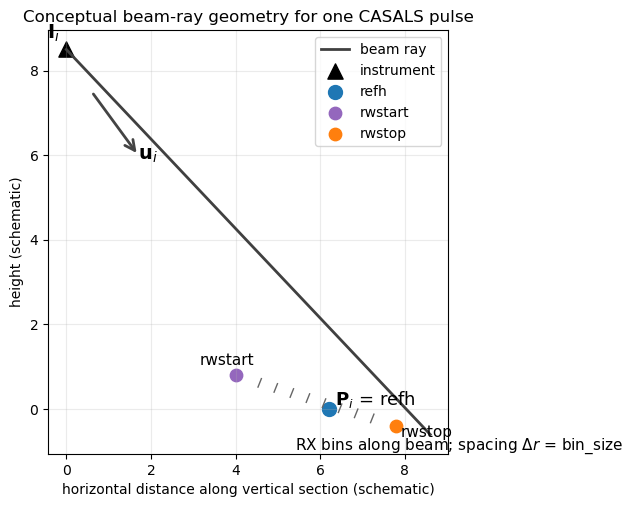

In [52]:
def plot_conceptual_beam_geometry() -> None:
    fig, ax = plt.subplots(figsize=(10, 5.5))

    I = np.array([0.0, 8.5])
    rwstart = np.array([4.0, 0.8])
    P = np.array([6.2, 0.0])
    rwstop = np.array([7.8, -0.4])

    ax.plot([I[0], rwstop[0] + 0.8], [I[1], rwstop[1] - 0.2], "-", lw=2, color="0.25", label="beam ray")
    ax.scatter([I[0]], [I[1]], s=120, marker="^", color="black", label="instrument")
    ax.scatter([P[0]], [P[1]], s=100, color="#1f77b4", label="refh")
    ax.scatter([rwstart[0]], [rwstart[1]], s=80, color="#9467bd", label="rwstart")
    ax.scatter([rwstop[0]], [rwstop[1]], s=80, color="#ff7f0e", label="rwstop")

    arrow = FancyArrowPatch(posA=(I[0] + 0.6, I[1] - 1.0), posB=(I[0] + 1.7, I[1] - 2.5),
                            arrowstyle="->", mutation_scale=18, lw=2, color="#444444")
    ax.add_patch(arrow)
    ax.text(I[0] + 1.7, I[1] - 2.6, r"$\mathbf{u}_i$", fontsize=14)

    for t in np.linspace(0.15, 0.85, 8):
        q = rwstart * (1 - t) + rwstop * t
        ax.plot([q[0] - 0.04, q[0] + 0.04], [q[1] - 0.10, q[1] + 0.10], color="0.4", lw=1)
    ax.text(5.4, -0.95, r"RX bins along beam; spacing $\Delta r$ = bin_size", fontsize=11)

    ax.text(I[0] - 0.45, I[1] + 0.25, r"$\mathbf{I}_i$", fontsize=14)
    ax.text(P[0] + 0.15, P[1] + 0.10, r"$\mathbf{P}_i$ = refh", fontsize=13)
    ax.text(rwstart[0] - 0.85, rwstart[1] + 0.25, "rwstart", fontsize=11)
    ax.text(rwstop[0] + 0.10, rwstop[1] - 0.25, "rwstop", fontsize=11)

    ax.set_title("Conceptual beam-ray geometry for one CASALS pulse")
    ax.set_xlabel("horizontal distance along vertical section (schematic)")
    ax.set_ylabel("height (schematic)")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right")
    ax.set_aspect("equal", adjustable="box")
    plt.show()

plot_conceptual_beam_geometry()

## 6. Beam-angle convention

Use East-North-Up coordinates:

$$
x=\text{Easting},\qquad y=\text{Northing},\qquad z=\text{Up}.
$$

Canonical no-bias rule:

$$
\mathbf{u}_i =
-
\begin{bmatrix}
\cos(e_i)\sin(a_i) \\
\cos(e_i)\cos(a_i) \\
\sin(e_i)
\end{bmatrix}.
$$

Beam ray:

$$
\mathbf{X}_i(r)=\mathbf{I}_i+r\mathbf{u}_i,\quad r>0.
$$

Direction agreement:

$$
\cos\theta_i =
\frac{\mathbf{u}_i\cdot(\mathbf{P}_i-\mathbf{I}_i)}
{\|\mathbf{P}_i-\mathbf{I}_i\|}.
$$

A correct forward ray should have $\cos\theta_i \approx 1$.

Optional empirical azimuth bias:

$$
a_i^* = a_i+\Delta a.
$$

Then:

$$
\mathbf{u}_i(\Delta a) =
-
\begin{bmatrix}
\cos(e_i)\sin(a_i+\Delta a) \\
\cos(e_i)\cos(a_i+\Delta a) \\
\sin(e_i)
\end{bmatrix}.
$$

This $\Delta a$ is a calibration hypothesis, not an official field definition.

In [53]:
def normalize_vectors(v: np.ndarray) -> np.ndarray:
    v = np.asarray(v, dtype=np.float64)
    norms = np.linalg.norm(v, axis=1)
    out = np.full_like(v, np.nan)
    valid = np.isfinite(norms) & (norms > 0)
    out[valid] = v[valid] / norms[valid, None]
    return out

def canonical_beam_unit_vectors(az: np.ndarray, el: np.ndarray, az_bias_deg: float = 0.0, el_bias_deg: float = 0.0) -> np.ndarray:
    az = np.asarray(az, dtype=np.float64) + np.deg2rad(float(az_bias_deg))
    el = np.asarray(el, dtype=np.float64) + np.deg2rad(float(el_bias_deg))
    u = -np.column_stack([
        np.cos(el) * np.sin(az),
        np.cos(el) * np.cos(az),
        np.sin(el),
    ])
    return normalize_vectors(u)

def line_point_distance(points: np.ndarray, line_points: np.ndarray, directions: np.ndarray) -> np.ndarray:
    points = np.asarray(points, dtype=np.float64)
    line_points = np.asarray(line_points, dtype=np.float64)
    directions = normalize_vectors(directions)
    w = points - line_points
    proj = np.sum(w * directions, axis=1)
    perp = w - proj[:, None] * directions
    return np.linalg.norm(perp, axis=1)

def signed_along_line(points: np.ndarray, line_points: np.ndarray, directions: np.ndarray) -> np.ndarray:
    return np.sum((np.asarray(points) - np.asarray(line_points)) * normalize_vectors(directions), axis=1)

def angle_error_to_segment_deg(refh_xyz: np.ndarray, instr_xyz: np.ndarray, directions: np.ndarray) -> np.ndarray:
    seg = refh_xyz - instr_xyz
    seg_unit = normalize_vectors(seg)
    directions = normalize_vectors(directions)
    cosv = np.sum(directions * seg_unit, axis=1)
    return np.degrees(np.arccos(np.clip(cosv, -1.0, 1.0)))

def fit_common_origin(line_points: np.ndarray, directions: np.ndarray) -> Tuple[np.ndarray, float]:
    eye = np.eye(3)
    A = np.zeros((3, 3), dtype=np.float64)
    b = np.zeros(3, dtype=np.float64)
    for p, u in zip(line_points, normalize_vectors(directions)):
        M = eye - np.outer(u, u)
        A += M
        b += M @ p
    cond = float(np.linalg.cond(A))
    try:
        x = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        x = np.linalg.lstsq(A, b, rcond=None)[0]
    return x, cond

def add_xyz_columns_if_needed(df: pd.DataFrame, epsg: int) -> pd.DataFrame:
    out = df.copy()
    if "refh_x" not in out.columns:
        out["refh_x"], out["refh_y"] = project_lonlat_to_xy(out["refh_lon"].to_numpy(), out["refh_lat"].to_numpy(), epsg)
    if "instrument_x" not in out.columns and {"instrument_lon", "instrument_lat"}.issubset(out.columns):
        out["instrument_x"], out["instrument_y"] = project_lonlat_to_xy(out["instrument_lon"].to_numpy(), out["instrument_lat"].to_numpy(), epsg)
    if {"rwstart_lon", "rwstart_lat"}.issubset(out.columns) and "rwstart_x" not in out.columns:
        out["rwstart_x"], out["rwstart_y"] = project_lonlat_to_xy(out["rwstart_lon"].to_numpy(), out["rwstart_lat"].to_numpy(), epsg)
    if {"rwstop_lon", "rwstop_lat"}.issubset(out.columns) and "rwstop_x" not in out.columns:
        out["rwstop_x"], out["rwstop_y"] = project_lonlat_to_xy(out["rwstop_lon"].to_numpy(), out["rwstop_lat"].to_numpy(), epsg)
    return out

## 7. Validate the canonical beam rule

For a point $\mathbf{Q}$, the distance to a ray line with point $\mathbf{I}_i$ and direction $\mathbf{u}_i$ is:

$$
d(\mathbf{Q},\mathbf{L}_i)
=
\left\|
(\mathbf{Q}-\mathbf{I}_i)
-
\left[(\mathbf{Q}-\mathbf{I}_i)\cdot\mathbf{u}_i\right]\mathbf{u}_i
\right\|.
$$

In this notebook, the no-bias canonical rule is the primary interpretation of the H5 beam-angle fields. The $+0.10^\circ$ azimuth bias is shown only as a sensitivity / calibration refinement. It must not be treated as an official CASALS angle convention.

Additional boundary conditions for interpretation:

- `az_bias` is not an H5 field.
- `az_bias` is not part of the beam-angle convention itself.
- It is an empirical refinement applied after the convention is fixed.
- The current $+0.10^\circ$ value comes from the sweep 7040 closure search used in this notebook.
- Because it lands on the current search-grid boundary, it cannot yet be treated as a stable boresight solution.
- Multi-sweep and multi-file validation are required before claiming systematic pointing calibration.


In [54]:
def compute_rule_metrics(df: pd.DataFrame, epsg: int, az_bias_deg: float = 0.0, el_bias_deg: float = 0.0) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    df = add_xyz_columns_if_needed(df, epsg)
    required = ["refh_x", "refh_y", "refh_z", "instrument_x", "instrument_y", "instrument_z", "beam_az", "beam_el"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    P = df[["refh_x", "refh_y", "refh_z"]].to_numpy(dtype=np.float64)
    I = df[["instrument_x", "instrument_y", "instrument_z"]].to_numpy(dtype=np.float64)
    U = canonical_beam_unit_vectors(df["beam_az"].to_numpy(), df["beam_el"].to_numpy(), az_bias_deg, el_bias_deg)

    line_to_refh = line_point_distance(P, I, U)
    angle_err = angle_error_to_segment_deg(P, I, U)
    seg = P - I
    seg_range = np.linalg.norm(seg, axis=1)
    seg_unit = normalize_vectors(seg)
    cosv = np.sum(U * seg_unit, axis=1)
    signed_ref_to_instr = signed_along_line(I, P, U)

    origin, cond = fit_common_origin(I, U)
    line_to_origin = line_point_distance(np.repeat(origin[None, :], P.shape[0], axis=0), I, U)

    out = df.copy()
    out["beam_line_to_refh_m"] = line_to_refh
    out["beam_angle_error_deg"] = angle_err
    out["beam_cosine_to_inst_to_refh"] = cosv
    out["instrument_to_refh_range_m"] = seg_range
    out["signed_range_refh_to_instrument_along_beam_m"] = signed_ref_to_instr
    out["beam_line_to_fit_origin_m"] = line_to_origin

    metrics = {
        "az_bias_deg": az_bias_deg,
        "el_bias_deg": el_bias_deg,
        "median_line_to_refh_m": float(np.nanmedian(line_to_refh)),
        "p90_line_to_refh_m": float(np.nanpercentile(line_to_refh, 90)),
        "median_angle_error_deg": float(np.nanmedian(angle_err)),
        "p90_angle_error_deg": float(np.nanpercentile(angle_err, 90)),
        "median_cosine_to_inst_to_refh": float(np.nanmedian(cosv)),
        "median_instrument_to_refh_range_m": float(np.nanmedian(seg_range)),
        "median_signed_refh_to_instrument_along_beam_m": float(np.nanmedian(signed_ref_to_instr)),
        "median_line_to_fit_origin_m": float(np.nanmedian(line_to_origin)),
        "origin_fit_condition_number": float(cond),
        "fit_origin_x": float(origin[0]),
        "fit_origin_y": float(origin[1]),
        "fit_origin_z": float(origin[2]),
    }
    return out, metrics

if not sweep_df.empty and EPSG is not None:
    base_per_track, base_metrics = compute_rule_metrics(sweep_df, EPSG, az_bias_deg=0.0, el_bias_deg=0.0)
    refined_per_track, refined_metrics = compute_rule_metrics(sweep_df, EPSG, az_bias_deg=AZ_BIAS_DEG, el_bias_deg=EL_BIAS_DEG)
    metrics_df = pd.DataFrame([base_metrics, refined_metrics])
    metrics_df.insert(0, "rule_version", ["canonical_no_bias", f"az_bias_{AZ_BIAS_DEG:+.2f}deg"])
    display(metrics_df)
else:
    base_per_track = pd.DataFrame()
    refined_per_track = pd.DataFrame()
    metrics_df = pd.DataFrame()

,rule_version,az_bias_deg,el_bias_deg,median_line_to_refh_m,p90_line_to_refh_m,median_angle_error_deg,p90_angle_error_deg,median_cosine_to_inst_to_refh,median_instrument_to_refh_range_m,median_signed_refh_to_instrument_along_beam_m,median_line_to_fit_origin_m,origin_fit_condition_number,fit_origin_x,fit_origin_y,fit_origin_z
0,canonical_no_bias,0.0,0.0,1.468566,1.558237,0.009785,0.010337,1.0,8626.822882,-8626.822757,0.044459,73039.382773,475041.220696,4.251435e+06,8591.324459
1,az_bias_+0.10deg,0.1,0.0,0.902538,0.955655,0.006008,0.006348,1.0,8626.822882,-8626.822835,0.044458,73039.382773,475041.220706,4.251435e+06,8591.321554


## 8. Range-window closure: rwstart, rwstop, and bin_size

Define `rwstart` and `rwstop` 3D points as:

$$
\mathbf{R}^{start}_i,\qquad \mathbf{R}^{stop}_i.
$$

Their signed positions relative to `refh` along the beam are:

$$
s_{start,i}=(\mathbf{R}^{start}_i-\mathbf{P}_i)\cdot\mathbf{u}_i,
$$

$$
s_{stop,i}=(\mathbf{R}^{stop}_i-\mathbf{P}_i)\cdot\mathbf{u}_i.
$$

The range-window length is:

$$
L_i=s_{stop,i}-s_{start,i}.
$$

This should be comparable to $N_{rx}\Delta r_i$ or $(N_{rx}-1)\Delta r_i$, depending on endpoint/bin-center interpretation.

In the 3D diagnostics below, any range-window segment is plotted as an angle-derived segment on the validated beam ray, not as a direct line drawn between the H5 `rwstart` and `rwstop` points. The residual traces show how far the H5 geolocated points deviate from that angle-derived segment.


In [55]:
def compute_range_window_closure(df: pd.DataFrame, epsg: int, az_bias_deg: float = 0.0, el_bias_deg: float = 0.0) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    df = add_xyz_columns_if_needed(df, epsg)
    required = [
        "refh_x", "refh_y", "refh_z",
        "instrument_x", "instrument_y", "instrument_z",
        "rwstart_x", "rwstart_y", "rwstart_z",
        "rwstop_x", "rwstop_y", "rwstop_z",
        "beam_az", "beam_el",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns for range-window closure: {missing}")

    I = df[["instrument_x", "instrument_y", "instrument_z"]].to_numpy(dtype=np.float64)
    P = df[["refh_x", "refh_y", "refh_z"]].to_numpy(dtype=np.float64)
    R0 = df[["rwstart_x", "rwstart_y", "rwstart_z"]].to_numpy(dtype=np.float64)
    R1 = df[["rwstop_x", "rwstop_y", "rwstop_z"]].to_numpy(dtype=np.float64)
    U = canonical_beam_unit_vectors(df["beam_az"].to_numpy(), df["beam_el"].to_numpy(), az_bias_deg, el_bias_deg)

    d_start = line_point_distance(R0, I, U)
    d_stop = line_point_distance(R1, I, U)
    s_start = signed_along_line(R0, P, U)
    s_stop = signed_along_line(R1, P, U)
    window_len = s_stop - s_start

    out = df.copy()
    out["rwstart_line_distance_m"] = d_start
    out["rwstop_line_distance_m"] = d_stop
    out["signed_refh_to_rwstart_m"] = s_start
    out["signed_refh_to_rwstop_m"] = s_stop
    out["rw_window_length_along_beam_m"] = window_len

    metrics = {
        "az_bias_deg": az_bias_deg,
        "median_rwstart_line_distance_m": float(np.nanmedian(d_start)),
        "median_rwstop_line_distance_m": float(np.nanmedian(d_stop)),
        "median_signed_refh_to_rwstart_m": float(np.nanmedian(s_start)),
        "median_signed_refh_to_rwstop_m": float(np.nanmedian(s_stop)),
        "median_rw_window_length_along_beam_m": float(np.nanmedian(window_len)),
    }

    if "bin_size" in df.columns:
        bin_size_median = float(np.nanmedian(df["bin_size"]))
        metrics["bin_size_median_m"] = bin_size_median
        n_rx = np.nan
        if H5_PATH.exists() and source_paths.get("rx_waveform") is not None:
            with h5py.File(H5_PATH, "r") as h5:
                n_rx = int(h5[source_paths["rx_waveform"]].shape[1])
        metrics["n_rx_bins"] = n_rx
        if np.isfinite(n_rx):
            metrics["n_rx_times_bin_size_m"] = float(n_rx * bin_size_median)
            metrics["n_rx_minus_1_times_bin_size_m"] = float((n_rx - 1) * bin_size_median)
            metrics["window_minus_n_rx_bin_size_m"] = metrics["median_rw_window_length_along_beam_m"] - metrics["n_rx_times_bin_size_m"]
            metrics["window_minus_n_rx_minus_1_bin_size_m"] = metrics["median_rw_window_length_along_beam_m"] - metrics["n_rx_minus_1_times_bin_size_m"]

    return out, metrics

if not sweep_df.empty and EPSG is not None and {"rwstart_lon", "rwstart_lat", "rwstart_z", "rwstop_lon", "rwstop_lat", "rwstop_z"}.issubset(sweep_df.columns):
    base_rw_df, base_rw_metrics = compute_range_window_closure(sweep_df, EPSG, az_bias_deg=0.0, el_bias_deg=0.0)
    refined_rw_df, refined_rw_metrics = compute_range_window_closure(sweep_df, EPSG, az_bias_deg=AZ_BIAS_DEG, el_bias_deg=EL_BIAS_DEG)
    rw_metrics_df = pd.DataFrame([base_rw_metrics, refined_rw_metrics])
    rw_metrics_df.insert(0, "rule_version", ["canonical_no_bias", f"az_bias_{AZ_BIAS_DEG:+.2f}deg"])
    display(rw_metrics_df)
else:
    base_rw_df = pd.DataFrame()
    refined_rw_df = pd.DataFrame()
    rw_metrics_df = pd.DataFrame()
    print("Range-window closure skipped because rwstart/rwstop fields are unavailable.")

,rule_version,az_bias_deg,median_rwstart_line_distance_m,median_rwstop_line_distance_m,median_signed_refh_to_rwstart_m,median_signed_refh_to_rwstop_m,median_rw_window_length_along_beam_m,bin_size_median_m,n_rx_bins,n_rx_times_bin_size_m,n_rx_minus_1_times_bin_size_m,window_minus_n_rx_bin_size_m,window_minus_n_rx_minus_1_bin_size_m
0,canonical_no_bias,0.0,1.440112,1.497131,-241.191504,167.611838,408.803335,0.149678,2728,408.320883,408.171205,0.482453,0.632130
1,az_bias_+0.10deg,0.1,0.891462,0.913433,-241.191506,167.611840,408.803339,0.149678,2728,408.320883,408.171205,0.482456,0.632134


## 9. Theory for geolocating other RX bins

### Instrument-anchored model

If $b$ is the RX bin index and $\Delta r_i$ is `bin_size`, then:

$$
r_{i,b}=r_{start,i}+(b+\alpha)\Delta r_i.
$$

Here $\alpha$ is the bin-center/bin-edge offset. Then:

$$
\mathbf{X}_{i,b}=\mathbf{I}_i+r_{i,b}\mathbf{u}_i.
$$

### Refh-anchored model

If the exact reference bin $b_{ref,i}$ is known:

$$
\mathbf{X}_{i,b}
=
\mathbf{P}_i+(b-b_{ref,i})\Delta r_i\mathbf{u}_i.
$$

This form is appealing because it anchors at the official refh point, but it requires strict knowledge of $b_{ref,i}$.

### Current status

The range-window closure supports the hypothesis that `bin_size` is an along-beam range spacing. The small diagnostic below does not export a full all-bin point cloud. It only checks whether one sweep can be parameterized consistently along the validated beam ray, and it reports a geometry-derived estimate of the `refh` bin from `rwstart`.

This geometry-derived estimated `refh` bin is not a strict waveform-derived `refh` bin.


In [56]:
def read_rx_waveform_shape(h5_path: Path, source_paths: Dict[str, Optional[str]]) -> Optional[tuple[int, ...]]:
    rx_path = source_paths.get("rx_waveform")
    if rx_path is None or not h5_path.exists():
        return None
    with h5py.File(h5_path, "r") as h5:
        return tuple(h5[rx_path].shape)


def estimate_refh_bin_from_range_window(
    df: pd.DataFrame,
    epsg: int,
    az_bias_deg: float = 0.0,
    el_bias_deg: float = 0.0,
    alpha: float = 0.0,
) -> pd.DataFrame:
    rw_df, _ = compute_range_window_closure(df, epsg, az_bias_deg=az_bias_deg, el_bias_deg=el_bias_deg)
    out = rw_df.copy()
    if "bin_size" not in out.columns:
        raise KeyError("bin_size is required for refh-bin estimation.")
    out["estimated_refh_bin_from_geometry"] = (-out["signed_refh_to_rwstart_m"]) / out["bin_size"] - alpha
    return out


if not sweep_df.empty and EPSG is not None and {"rwstart_lon", "rwstart_lat", "rwstart_z", "bin_size"}.issubset(sweep_df.columns):
    refh_bin_diag = estimate_refh_bin_from_range_window(
        sweep_df,
        EPSG,
        az_bias_deg=0.0,
        el_bias_deg=0.0,
        alpha=0.0,
    )
    rx_waveform_shape = read_rx_waveform_shape(H5_PATH, source_paths)
    n_rx_bins = int(rx_waveform_shape[1]) if rx_waveform_shape and len(rx_waveform_shape) >= 2 else np.nan

    b_ref_est = pd.to_numeric(refh_bin_diag["estimated_refh_bin_from_geometry"], errors="coerce").to_numpy(dtype=np.float64)
    finite = np.isfinite(b_ref_est)
    if finite.any():
        refh_bin_summary_df = pd.DataFrame(
            [
                {
                    "n_rx_bins": n_rx_bins,
                    "count_finite": int(finite.sum()),
                    "min": float(np.nanmin(b_ref_est[finite])),
                    "p10": float(np.nanpercentile(b_ref_est[finite], 10)),
                    "median": float(np.nanmedian(b_ref_est[finite])),
                    "p90": float(np.nanpercentile(b_ref_est[finite], 90)),
                    "max": float(np.nanmax(b_ref_est[finite])),
                }
            ]
        )
    else:
        refh_bin_summary_df = pd.DataFrame(
            [{"n_rx_bins": n_rx_bins, "count_finite": 0, "min": np.nan, "p10": np.nan, "median": np.nan, "p90": np.nan, "max": np.nan}]
        )

    display(refh_bin_summary_df)
    display(
        refh_bin_diag[
            [
                "track_num",
                "signed_refh_to_rwstart_m",
                "signed_refh_to_rwstop_m",
                "bin_size",
                "estimated_refh_bin_from_geometry",
            ]
        ].head(20)
    )
    print("The table above is a geometry-derived estimated refh bin diagnostic, not a strict waveform-derived refh bin.")
else:
    refh_bin_diag = pd.DataFrame()
    refh_bin_summary_df = pd.DataFrame()


,n_rx_bins,count_finite,min,p10,median,p90,max
0,2728,256,12.513745,612.188127,1611.340436,1757.982897,2714.715035


,track_num,signed_refh_to_rwstart_m,signed_refh_to_rwstop_m,bin_size,estimated_refh_bin_from_geometry
0,0,-128.800507,280.002861,0.149699,860.399364
1,1,-240.292394,168.510974,0.149698,1605.176818
2,2,-63.913278,344.890089,0.149698,426.947557
3,3,-271.761818,137.041549,0.149698,1815.400397
4,4,-92.985167,315.818199,0.149698,621.152156
5,5,-240.292393,168.510973,0.149698,1605.184146
6,6,-240.292393,168.510973,0.149698,1605.183995
7,7,-242.090646,166.712720,0.149698,1617.198841
8,8,-240.592102,168.211264,0.149697,1607.190015
9,9,-16.858730,391.944636,0.149697,112.618832


The table above is a geometry-derived estimated refh bin diagnostic, not a strict waveform-derived refh bin.


## 10. Broad-audit result tables

A common-origin score alone can be misleading. The correct rule must also pass physical checks: ray-to-refh distance, angle error, cosine direction, H5 height consistency, and rwstart/rwstop closure.

In [57]:
def read_optional_csv(path: Path) -> Optional[pd.DataFrame]:
    if path.exists():
        print("Loaded:", path)
        return pd.read_csv(path)
    print("Not found:", path)
    return None

compact_scores = read_optional_csv(COMPACT_SCORES_CSV)
recommended_rules = read_optional_csv(RECOMMENDED_RULES_CSV)

if recommended_rules is not None:
    display(recommended_rules.head(20))

if compact_scores is not None:
    key_cols = [
        "rank_by_physical_score", "rank_by_cross_anchor", "rank_by_convergence", "rank_by_angle_error",
        "rule_key", "rule_passes_strict_physical_gate", "physical_score",
        "median_cross_anchor_line_error_m", "median_angle_error_to_segment_deg",
        "median_cosine_to_inst_to_ref", "fit_origin_height_error_vs_h5_platform_height_m",
        "median_line_to_rwstart_m", "median_line_to_rwstop_m",
        "h5_median_instrument_height_above_median_refh_m",
        "h5_platform_height_error_to_expected_agl_band_m",
    ]
    key_cols = [c for c in key_cols if c in compact_scores.columns]
    display(compact_scores[key_cols].head(30))

Not found: ..\beam_line_origin\scores\sw_7040_origin_scores_compact.csv
Not found: ..\beam_line_origin\scores\sw_7040_recommended_physical_rules.csv


## 11. Real-coordinate interactive 3D visualization

The Plotly views below show the selected sweep in a metric projected coordinate system. Coordinates are centered at the median instrument position for numerical stability:

$$
x'=x-\tilde{X}_{inst},\qquad
y'=y-\tilde{Y}_{inst},\qquad
z'=z.
$$

The key change in this notebook is that the beam-ray traces are now angle-derived. They are computed from `local_beam_azimuth` and `local_beam_elevation`, optionally perturbed by the visualization bias settings, and then projected toward the H5 points. The figure no longer draws a direct `instrument -> refh` segment and calls it a beam ray.

Objects:

- bright blue: official H5 `refh` points;
- deep navy: H5 instrument positions;
- slate blue lines: angle-derived beam rays from instrument to the projected point `P_ray`;
- rose lines: residual from the angle-derived ray to the H5 `refh` point;
- magenta / amber markers: H5 `rwstart` / `rwstop` points;
- violet line segment: angle-derived `rwstart -> rwstop` segment on the validated ray;
- pale residual lines: offset from the angle-derived range-window segment back to the H5 `rwstart` / `rwstop` points.

Two aspect treatments are shown:

- **Figure A: true metric aspect** uses `aspectmode="data"` and preserves equal metric scaling.
- **Figure B: adaptive aspect** is shown only for readability. Metric coordinates are preserved, but the displayed axis scales are not equal.


In [58]:
def _axis_range(values: np.ndarray, pad_fraction: float = 0.08, min_pad: float = 1.0) -> Tuple[list[float], float]:
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return [-1.0, 1.0], 2.0
    lower = float(np.nanmin(finite))
    upper = float(np.nanmax(finite))
    span = max(upper - lower, 1.0)
    pad = max(span * pad_fraction, min_pad)
    return [lower - pad, upper + pad], span + 2.0 * pad


def _scene_axis(title: str, axis_range: Sequence[float]) -> Dict[str, Any]:
    return dict(
        title=title,
        range=list(axis_range),
        showbackground=True,
        backgroundcolor=PLOTLY_3D_COLORS["background"],
        gridcolor=PLOTLY_3D_COLORS["grid"],
        zerolinecolor=PLOTLY_3D_COLORS["zero"],
        showspikes=False,
    )


def _adaptive_scene_layout(
    x_values: np.ndarray,
    y_values: np.ndarray,
    z_values: np.ndarray,
    x_title: str,
    y_title: str,
    z_title: str,
) -> Dict[str, Any]:
    x_range, x_span = _axis_range(x_values)
    y_range, y_span = _axis_range(y_values)
    z_range, z_span = _axis_range(z_values)

    spans = np.array([x_span, y_span, z_span], dtype=np.float64)
    max_span = float(np.nanmax(spans)) if np.isfinite(spans).any() else 1.0
    ratios = np.clip(spans / max_span, ADAPTIVE_AXIS_MIN_RATIO, 1.0)
    ratios /= ratios.max()

    return dict(
        xaxis=_scene_axis(x_title, x_range),
        yaxis=_scene_axis(y_title, y_range),
        zaxis=_scene_axis(z_title, z_range),
        aspectmode="manual",
        aspectratio=dict(x=float(ratios[0]), y=float(ratios[1]), z=float(ratios[2])),
        camera=dict(eye=dict(x=1.6, y=1.45, z=0.9)),
    )


def _true_metric_scene_layout(
    x_values: np.ndarray,
    y_values: np.ndarray,
    z_values: np.ndarray,
    x_title: str,
    y_title: str,
    z_title: str,
) -> Dict[str, Any]:
    x_range, _ = _axis_range(x_values)
    y_range, _ = _axis_range(y_values)
    z_range, _ = _axis_range(z_values)
    return dict(
        xaxis=_scene_axis(x_title, x_range),
        yaxis=_scene_axis(y_title, y_range),
        zaxis=_scene_axis(z_title, z_range),
        aspectmode="data",
        camera=dict(eye=dict(x=1.6, y=1.45, z=0.9)),
    )


def make_sweep_3d_figure(
    df: pd.DataFrame,
    epsg: int,
    az_bias_deg: float = 0.0,
    el_bias_deg: float = 0.0,
    max_rays: int = 256,
    draw_rw: bool = True,
    title: str = "CASALS sweep beam geometry",
    aspect_mode: str = "true_metric",
) -> go.Figure:
    df = add_xyz_columns_if_needed(df, epsg).copy()

    P = df[["refh_x", "refh_y", "refh_z"]].to_numpy(dtype=np.float64)
    I = df[["instrument_x", "instrument_y", "instrument_z"]].to_numpy(dtype=np.float64)
    U = canonical_beam_unit_vectors(
        df["beam_az"].to_numpy(),
        df["beam_el"].to_numpy(),
        az_bias_deg=az_bias_deg,
        el_bias_deg=el_bias_deg,
    )

    line_to_refh = line_point_distance(P, I, U)
    angle_err = angle_error_to_segment_deg(P, I, U)
    r_ref = np.sum((P - I) * U, axis=1)
    P_ray = I + r_ref[:, None] * U

    center = np.nanmedian(I, axis=0)
    center_offset = np.array([center[0], center[1], 0.0], dtype=np.float64)
    Pp = P - center_offset
    Ip = I - center_offset
    P_ray_p = P_ray - center_offset

    extra_arrays = [Pp, Ip, P_ray_p]
    valid_mask = (
        np.isfinite(P).all(axis=1)
        & np.isfinite(I).all(axis=1)
        & np.isfinite(U).all(axis=1)
        & np.isfinite(line_to_refh)
        & np.isfinite(angle_err)
        & np.isfinite(r_ref)
    )

    fig = go.Figure()

    hover_refh = [
        (
            f"track={int(t)}<br>record={int(r)}<br>lon={lon:.8f}<br>lat={lat:.8f}<br>"
            f"refh={z:.3f} m<br>line-to-ray={d:.3f} m<br>angle error={a:.6f} deg"
        )
        for t, r, lon, lat, z, d, a in zip(
            df["track_num"],
            df["record_index"],
            df["refh_lon"],
            df["refh_lat"],
            df["refh_z"],
            line_to_refh,
            angle_err,
        )
    ]

    fig.add_trace(
        go.Scatter3d(
            x=Pp[:, 0],
            y=Pp[:, 1],
            z=Pp[:, 2],
            mode="markers",
            marker=dict(
                size=4,
                color=PLOTLY_3D_COLORS["refh"],
                line=dict(width=0.6, color="rgba(15,23,42,0.35)"),
            ),
            name="refh points",
            text=hover_refh,
            hoverinfo="text",
        )
    )

    fig.add_trace(
        go.Scatter3d(
            x=Ip[:, 0],
            y=Ip[:, 1],
            z=Ip[:, 2],
            mode="markers",
            marker=dict(
                size=3.5,
                color=PLOTLY_3D_COLORS["instrument"],
                line=dict(width=0.5, color="rgba(15,23,42,0.28)"),
            ),
            name="instrument positions",
            text=[
                f"track={int(t)}<br>instrument z={z:.3f} m<br>beam az={az:.6f} rad<br>beam el={el:.6f} rad"
                for t, z, az, el in zip(df["track_num"], df["instrument_z"], df["beam_az"], df["beam_el"])
            ],
            hoverinfo="text",
        )
    )

    med_inst = np.nanmedian(Ip, axis=0)
    fig.add_trace(
        go.Scatter3d(
            x=[med_inst[0]],
            y=[med_inst[1]],
            z=[med_inst[2]],
            mode="markers",
            marker=dict(
                size=9,
                color=PLOTLY_3D_COLORS["median_instrument"],
                symbol="diamond",
                line=dict(width=1.0, color="rgba(15,23,42,0.45)"),
            ),
            name="median instrument",
        )
    )

    valid_ids = np.flatnonzero(valid_mask)
    if valid_ids.size > max_rays:
        sample_ids = np.linspace(0, valid_ids.size - 1, max_rays).round().astype(int)
        valid_ids = valid_ids[sample_ids]

    xs, ys, zs = [], [], []
    res_x, res_y, res_z = [], [], []
    for idx in valid_ids:
        xs += [Ip[idx, 0], P_ray_p[idx, 0], None]
        ys += [Ip[idx, 1], P_ray_p[idx, 1], None]
        zs += [Ip[idx, 2], P_ray_p[idx, 2], None]
        res_x += [P_ray_p[idx, 0], Pp[idx, 0], None]
        res_y += [P_ray_p[idx, 1], Pp[idx, 1], None]
        res_z += [P_ray_p[idx, 2], Pp[idx, 2], None]

    fig.add_trace(
        go.Scatter3d(
            x=xs,
            y=ys,
            z=zs,
            mode="lines",
            line=dict(color=PLOTLY_3D_COLORS["rays"], width=3),
            name="angle-derived beam rays",
            hoverinfo="skip",
        )
    )
    fig.add_trace(
        go.Scatter3d(
            x=res_x,
            y=res_y,
            z=res_z,
            mode="lines",
            line=dict(color="rgba(244,63,94,0.55)", width=2),
            name="ray-to-refh residual",
            hoverinfo="skip",
        )
    )

    if draw_rw and {"rwstart_x", "rwstart_y", "rwstart_z", "rwstop_x", "rwstop_y", "rwstop_z"}.issubset(df.columns):
        R0 = df[["rwstart_x", "rwstart_y", "rwstart_z"]].to_numpy(dtype=np.float64)
        R1 = df[["rwstop_x", "rwstop_y", "rwstop_z"]].to_numpy(dtype=np.float64)
        r_start = np.sum((R0 - I) * U, axis=1)
        r_stop = np.sum((R1 - I) * U, axis=1)
        R0_ray = I + r_start[:, None] * U
        R1_ray = I + r_stop[:, None] * U

        R0p = R0 - center_offset
        R1p = R1 - center_offset
        R0_ray_p = R0_ray - center_offset
        R1_ray_p = R1_ray - center_offset
        extra_arrays.extend([R0p, R1p, R0_ray_p, R1_ray_p])

        rwstart_resid = np.linalg.norm(R0 - R0_ray, axis=1)
        rwstop_resid = np.linalg.norm(R1 - R1_ray, axis=1)

        fig.add_trace(
            go.Scatter3d(
                x=R0p[:, 0],
                y=R0p[:, 1],
                z=R0p[:, 2],
                mode="markers",
                marker=dict(
                    size=3,
                    color=PLOTLY_3D_COLORS["rwstart"],
                    line=dict(width=0.5, color="rgba(15,23,42,0.28)"),
                ),
                name="H5 rwstart",
                text=[
                    f"track={int(t)}<br>rwstart={z:.3f} m<br>line-to-ray={d:.3f} m"
                    for t, z, d in zip(df["track_num"], df["rwstart_z"], rwstart_resid)
                ],
                hoverinfo="text",
            )
        )
        fig.add_trace(
            go.Scatter3d(
                x=R1p[:, 0],
                y=R1p[:, 1],
                z=R1p[:, 2],
                mode="markers",
                marker=dict(
                    size=3,
                    color=PLOTLY_3D_COLORS["rwstop"],
                    line=dict(width=0.5, color="rgba(15,23,42,0.28)"),
                ),
                name="H5 rwstop",
                text=[
                    f"track={int(t)}<br>rwstop={z:.3f} m<br>line-to-ray={d:.3f} m"
                    for t, z, d in zip(df["track_num"], df["rwstop_z"], rwstop_resid)
                ],
                hoverinfo="text",
            )
        )

        rw_valid_mask = valid_mask & np.isfinite(R0).all(axis=1) & np.isfinite(R1).all(axis=1)
        rw_valid_ids = np.flatnonzero(rw_valid_mask)
        if rw_valid_ids.size > max_rays:
            sample_ids = np.linspace(0, rw_valid_ids.size - 1, max_rays).round().astype(int)
            rw_valid_ids = rw_valid_ids[sample_ids]

        rw_x, rw_y, rw_z = [], [], []
        rw_res_x, rw_res_y, rw_res_z = [], [], []
        for idx in rw_valid_ids:
            rw_x += [R0_ray_p[idx, 0], R1_ray_p[idx, 0], None]
            rw_y += [R0_ray_p[idx, 1], R1_ray_p[idx, 1], None]
            rw_z += [R0_ray_p[idx, 2], R1_ray_p[idx, 2], None]

            rw_res_x += [R0_ray_p[idx, 0], R0p[idx, 0], None, R1_ray_p[idx, 0], R1p[idx, 0], None]
            rw_res_y += [R0_ray_p[idx, 1], R0p[idx, 1], None, R1_ray_p[idx, 1], R1p[idx, 1], None]
            rw_res_z += [R0_ray_p[idx, 2], R0p[idx, 2], None, R1_ray_p[idx, 2], R1p[idx, 2], None]

        fig.add_trace(
            go.Scatter3d(
                x=rw_x,
                y=rw_y,
                z=rw_z,
                mode="lines",
                line=dict(color="rgba(147,51,234,0.72)", width=3),
                name="angle-derived rwstart->rwstop ray segment",
                hoverinfo="skip",
            )
        )
        fig.add_trace(
            go.Scatter3d(
                x=rw_res_x,
                y=rw_res_y,
                z=rw_res_z,
                mode="lines",
                line=dict(color="rgba(168,85,247,0.28)", width=2),
                name="rwstart/rwstop residuals",
                hoverinfo="skip",
            )
        )

    stacked = np.vstack(extra_arrays)
    if aspect_mode == "true_metric":
        scene = _true_metric_scene_layout(
            stacked[:, 0],
            stacked[:, 1],
            stacked[:, 2],
            "Easting offset (m)",
            "Northing offset (m)",
            "Height (m)",
        )
    elif aspect_mode == "adaptive":
        scene = _adaptive_scene_layout(
            stacked[:, 0],
            stacked[:, 1],
            stacked[:, 2],
            "Easting offset (m)",
            "Northing offset (m)",
            "Height (m)",
        )
    else:
        raise ValueError(f"Unsupported aspect_mode={aspect_mode!r}")

    fig.update_layout(
        title=title,
        scene=scene,
        paper_bgcolor="white",
        legend=dict(
            x=0.01,
            y=0.99,
            bgcolor="rgba(255,255,255,0.85)",
            bordercolor="rgba(148,163,184,0.55)",
            borderwidth=1,
        ),
        margin=dict(l=0, r=0, t=52, b=0),
        height=750,
    )
    return fig


if not sweep_df.empty and EPSG is not None:
    vis_az_bias = AZ_BIAS_DEG if USE_AZ_BIAS_REFINEMENT_FOR_VISUALIZATION else 0.0
    rule_label = "bias-refined" if USE_AZ_BIAS_REFINEMENT_FOR_VISUALIZATION else "canonical no-bias"

    true_metric_fig = make_sweep_3d_figure(
        sweep_df,
        EPSG,
        az_bias_deg=vis_az_bias,
        el_bias_deg=EL_BIAS_DEG,
        max_rays=MAX_RAYS_TO_DRAW,
        draw_rw=DRAW_RWSTART_RWSTOP,
        title=f"Sweep {SWEEP_INDEX}: angle-derived beam geometry ({rule_label}, true metric aspect)",
        aspect_mode="true_metric",
    )
    adaptive_fig = make_sweep_3d_figure(
        sweep_df,
        EPSG,
        az_bias_deg=vis_az_bias,
        el_bias_deg=EL_BIAS_DEG,
        max_rays=MAX_RAYS_TO_DRAW,
        draw_rw=DRAW_RWSTART_RWSTOP,
        title=(
            f"Sweep {SWEEP_INDEX}: angle-derived beam geometry "
            f"({rule_label}, adaptive aspect for readability only)"
        ),
        aspect_mode="adaptive",
    )

    true_metric_fig.show()
    adaptive_fig.show()
else:
    print("Cannot build 3D figure without sweep data.")


## 12. Visualization sanity check

The check below confirms that the 3D ray endpoints are the angle-derived projection points `P_ray`, not the H5 `refh` points themselves. If the implementation is correct, the median `|P_ray - P|` should match the median line-to-ray distance used in the closure metrics.


In [59]:
if not sweep_df.empty and EPSG is not None:
    vis_az_bias = AZ_BIAS_DEG if USE_AZ_BIAS_REFINEMENT_FOR_VISUALIZATION else 0.0
    expected_metrics = refined_metrics if USE_AZ_BIAS_REFINEMENT_FOR_VISUALIZATION else base_metrics

    sanity_df = add_xyz_columns_if_needed(sweep_df, EPSG).copy()
    P = sanity_df[["refh_x", "refh_y", "refh_z"]].to_numpy(dtype=np.float64)
    I = sanity_df[["instrument_x", "instrument_y", "instrument_z"]].to_numpy(dtype=np.float64)
    U = canonical_beam_unit_vectors(
        sanity_df["beam_az"].to_numpy(),
        sanity_df["beam_el"].to_numpy(),
        az_bias_deg=vis_az_bias,
        el_bias_deg=EL_BIAS_DEG,
    )

    r_ref = np.sum((P - I) * U, axis=1)
    P_ray = I + r_ref[:, None] * U
    ray_endpoint_error = np.linalg.norm(P_ray - P, axis=1)
    median_ray_endpoint_error = float(np.nanmedian(ray_endpoint_error))
    expected_median = float(expected_metrics["median_line_to_refh_m"])
    matches_metric = bool(
        np.isfinite(median_ray_endpoint_error)
        and np.isfinite(expected_median)
        and np.isclose(median_ray_endpoint_error, expected_median, rtol=1e-6, atol=1e-6)
    )

    print("Median ray endpoint to H5 refh:", median_ray_endpoint_error)
    print("Expected median_line_to_refh_m:", expected_median)
    print("Matches median_line_to_refh_m:", matches_metric)

    if np.isfinite(median_ray_endpoint_error) and median_ray_endpoint_error <= 0.0:
        print("Warning: median ray endpoint residual is non-positive; inspect the visualization logic.")
    elif not matches_metric:
        print("Warning: projected ray endpoint residual does not match the line-to-refh metric.")
    else:
        print("Sanity check passed: the plotted ray endpoint is the angle-derived projection point, not a forced instrument-to-refh line.")
else:
    print("Visualization sanity check skipped because sweep data are unavailable.")


Median ray endpoint to H5 refh: 1.4685657782066426
Expected median_line_to_refh_m: 1.4685657784465942
Matches median_line_to_refh_m: True
Sanity check passed: the plotted ray endpoint is the angle-derived projection point, not a forced instrument-to-refh line.


## 13. Ground-level zoom view

This view omits the instrument position and focuses on the near-surface geometry of the H5 `refh`, `rwstart`, and `rwstop` points.


In [60]:
def make_ground_zoom_figure(df: pd.DataFrame, epsg: int, title: str = "Ground-level range-window zoom") -> go.Figure:
    df = add_xyz_columns_if_needed(df, epsg).copy()
    P = df[["refh_x", "refh_y", "refh_z"]].to_numpy(dtype=np.float64)
    center_xy = np.nanmedian(P[:, :2], axis=0)
    center_offset = np.array([center_xy[0], center_xy[1], 0.0])
    fig = go.Figure()

    Pp = P - center_offset
    extra_arrays = [Pp]
    fig.add_trace(go.Scatter3d(
        x=Pp[:, 0], y=Pp[:, 1], z=Pp[:, 2],
        mode="markers",
        marker=dict(
            size=4.5,
            color=PLOTLY_3D_COLORS["refh"],
            line=dict(width=0.6, color="rgba(15,23,42,0.35)"),
        ),
        name="refh",
        text=[f"track={int(t)}<br>refh={z:.3f} m" for t, z in zip(df["track_num"], df["refh_z"])],
        hoverinfo="text",
    ))

    if {"rwstart_x", "rwstart_y", "rwstart_z", "rwstop_x", "rwstop_y", "rwstop_z"}.issubset(df.columns):
        R0 = df[["rwstart_x", "rwstart_y", "rwstart_z"]].to_numpy(dtype=np.float64)
        R1 = df[["rwstop_x", "rwstop_y", "rwstop_z"]].to_numpy(dtype=np.float64)
        R0p = R0 - center_offset
        R1p = R1 - center_offset
        extra_arrays.extend([R0p, R1p])

        fig.add_trace(go.Scatter3d(
            x=R0p[:, 0], y=R0p[:, 1], z=R0p[:, 2],
            mode="markers",
            marker=dict(
                size=3.5,
                color=PLOTLY_3D_COLORS["rwstart"],
                line=dict(width=0.5, color="rgba(15,23,42,0.28)"),
            ),
            name="rwstart",
            hoverinfo="skip",
        ))
        fig.add_trace(go.Scatter3d(
            x=R1p[:, 0], y=R1p[:, 1], z=R1p[:, 2],
            mode="markers",
            marker=dict(
                size=3.5,
                color=PLOTLY_3D_COLORS["rwstop"],
                line=dict(width=0.5, color="rgba(15,23,42,0.28)"),
            ),
            name="rwstop",
            hoverinfo="skip",
        ))

    stacked = np.vstack(extra_arrays)
    fig.update_layout(
        title=title,
        scene=_adaptive_scene_layout(
            stacked[:, 0],
            stacked[:, 1],
            stacked[:, 2],
            "Easting offset from median refh (m)",
            "Northing offset from median refh (m)",
            "Height (m)",
        ),
        paper_bgcolor="white",
        legend=dict(
            x=0.01,
            y=0.99,
            bgcolor="rgba(255,255,255,0.85)",
            bordercolor="rgba(148,163,184,0.55)",
            borderwidth=1,
        ),
        height=700,
        margin=dict(l=0, r=0, t=52, b=0),
    )
    return fig


if not sweep_df.empty and EPSG is not None:
    make_ground_zoom_figure(
        sweep_df,
        EPSG,
        title=f"Sweep {SWEEP_INDEX}: ground-level refh/rwstart/rwstop geometry",
    ).show()

## 14. Per-track diagnostic plots


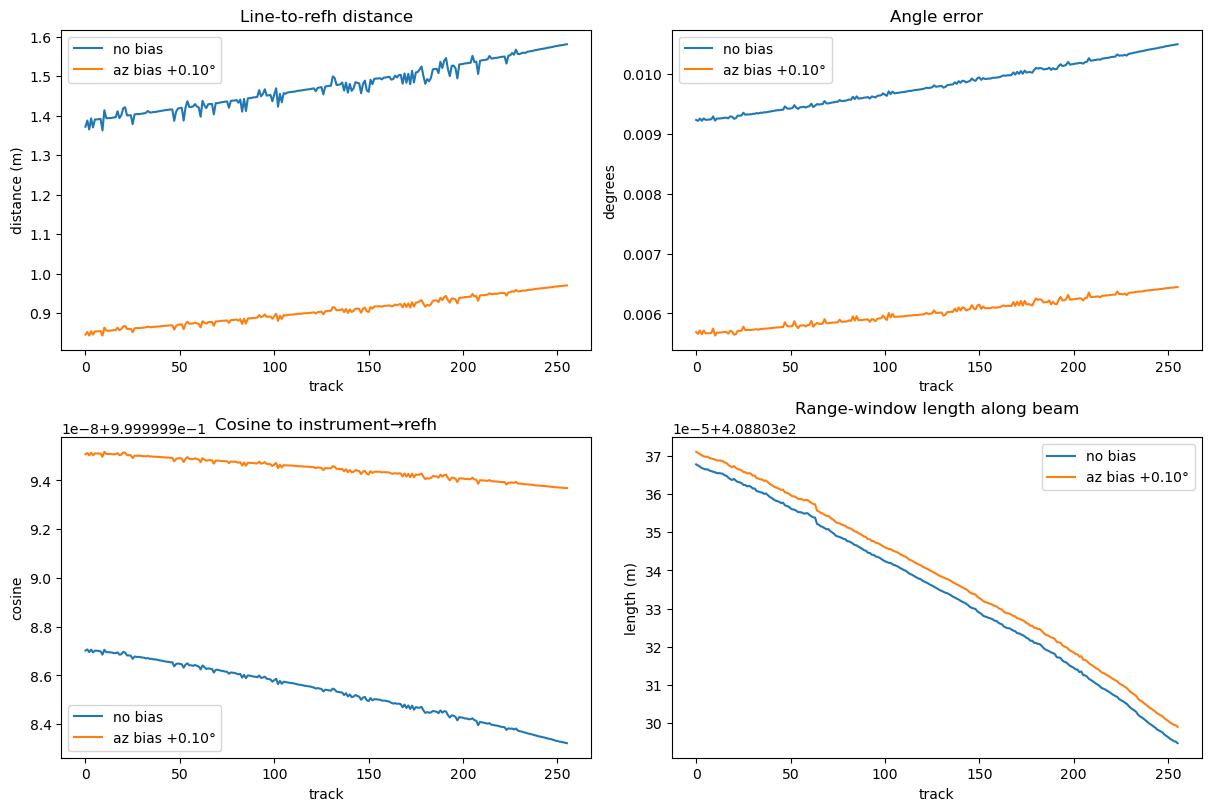

In [61]:
if not base_per_track.empty:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

    axes[0, 0].plot(base_per_track["track_num"], base_per_track["beam_line_to_refh_m"], label="no bias")
    axes[0, 0].plot(refined_per_track["track_num"], refined_per_track["beam_line_to_refh_m"], label=f"az bias {AZ_BIAS_DEG:+.2f}°")
    axes[0, 0].set_title("Line-to-refh distance")
    axes[0, 0].set_xlabel("track")
    axes[0, 0].set_ylabel("distance (m)")
    axes[0, 0].legend()

    axes[0, 1].plot(base_per_track["track_num"], base_per_track["beam_angle_error_deg"], label="no bias")
    axes[0, 1].plot(refined_per_track["track_num"], refined_per_track["beam_angle_error_deg"], label=f"az bias {AZ_BIAS_DEG:+.2f}°")
    axes[0, 1].set_title("Angle error")
    axes[0, 1].set_xlabel("track")
    axes[0, 1].set_ylabel("degrees")
    axes[0, 1].legend()

    axes[1, 0].plot(base_per_track["track_num"], base_per_track["beam_cosine_to_inst_to_refh"], label="no bias")
    axes[1, 0].plot(refined_per_track["track_num"], refined_per_track["beam_cosine_to_inst_to_refh"], label=f"az bias {AZ_BIAS_DEG:+.2f}°")
    axes[1, 0].set_title("Cosine to instrument→refh")
    axes[1, 0].set_xlabel("track")
    axes[1, 0].set_ylabel("cosine")
    axes[1, 0].legend()

    if not base_rw_df.empty:
        axes[1, 1].plot(base_rw_df["track_num"], base_rw_df["rw_window_length_along_beam_m"], label="no bias")
        axes[1, 1].plot(refined_rw_df["track_num"], refined_rw_df["rw_window_length_along_beam_m"], label=f"az bias {AZ_BIAS_DEG:+.2f}°")
        axes[1, 1].set_title("Range-window length along beam")
        axes[1, 1].set_xlabel("track")
        axes[1, 1].set_ylabel("length (m)")
        axes[1, 1].legend()
    else:
        axes[1, 1].axis("off")

    plt.show()
else:
    print("No per-track metrics available.")

## 15. Optional waveform inspection


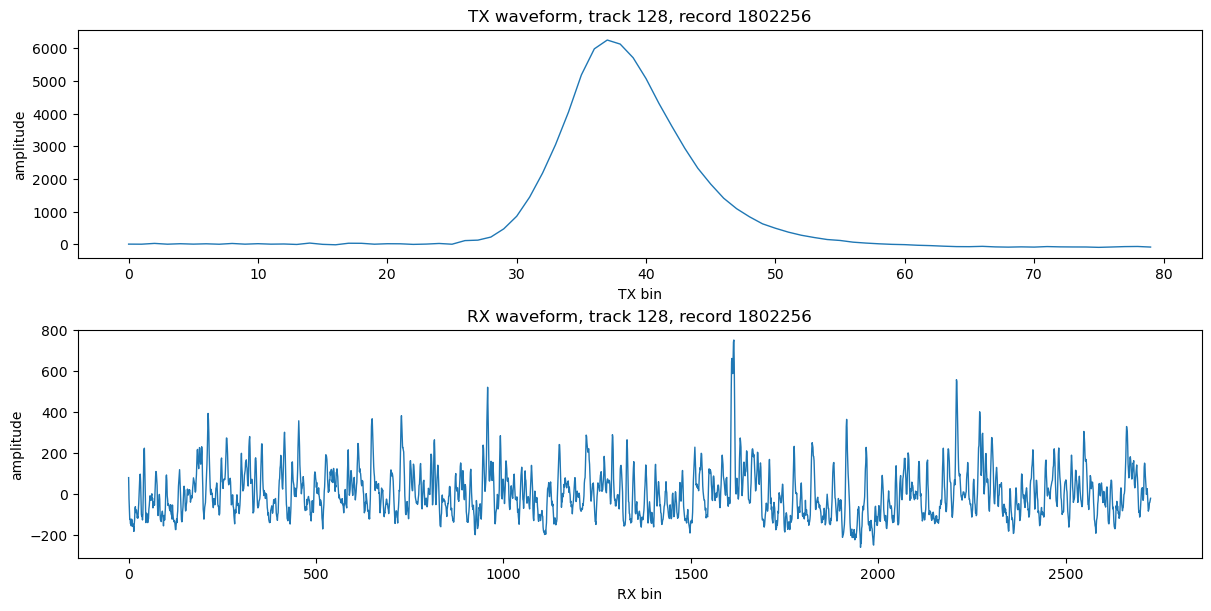

In [62]:
TRACK_TO_VIEW = 128

def read_one_waveform(h5_path: Path, record_index: int) -> Tuple[Optional[np.ndarray], Optional[np.ndarray]]:
    with h5py.File(h5_path, "r") as h5:
        rx_path = find_dataset_path(h5, DATASET_CANDIDATES["rx_waveform"], required=False)
        tx_path = find_dataset_path(h5, DATASET_CANDIDATES["tx_waveform"], required=False)
        rx = None if rx_path is None else np.asarray(h5[rx_path][record_index, :])
        tx = None if tx_path is None else np.asarray(h5[tx_path][record_index, :])
        return rx, tx

if H5_PATH.exists() and not sweep_df.empty:
    row_match = sweep_df.loc[sweep_df["track_num"] == TRACK_TO_VIEW]
    if row_match.empty:
        print(f"Track {TRACK_TO_VIEW} not found.")
    else:
        rec = int(row_match.iloc[0]["record_index"])
        rx, tx = read_one_waveform(H5_PATH, rec)

        fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)

        if tx is not None:
            axes[0].plot(tx, lw=1)
            axes[0].set_title(f"TX waveform, track {TRACK_TO_VIEW}, record {rec}")
            axes[0].set_xlabel("TX bin")
            axes[0].set_ylabel("amplitude")
        else:
            axes[0].text(0.5, 0.5, "No TX waveform", ha="center", va="center")

        if rx is not None:
            axes[1].plot(rx, lw=1)
            axes[1].set_title(f"RX waveform, track {TRACK_TO_VIEW}, record {rec}")
            axes[1].set_xlabel("RX bin")
            axes[1].set_ylabel("amplitude")
        else:
            axes[1].text(0.5, 0.5, "No RX waveform", ha="center", va="center")

        plt.show()
else:
    print("Missing H5 or sweep data.")

## 16. Status summary

### Established

1. H5 contains the core georeference fields required for this audit.
2. The canonical no-bias beam convention produces meter-level closure to `refh`.
3. `rwstart` and `rwstop` also close to the same angle-derived beam line.
4. H5 `instrument_altitude` and `refh` are internally consistent with an 8.5-km-scale airborne geometry for this example sweep.

### Likely

1. `bin_size` likely represents along-beam range spacing.
2. The full RX range window can likely be parameterized along the validated beam ray.
3. A small positive azimuth bias improves this sweep's closure.

### Unresolved

1. Exact `refh` bin.
2. Bin-center versus bin-edge convention.
3. Bin index direction.
4. Multi-sweep stability of the azimuth bias.
5. External vertical datum of `instrument_altitude` and `refh`.
6. Role of range, tide, and atmospheric correction fields in production geolocation.


## 17. Recommended next checks

1. **Multi-sweep validation**: repeat the metrics for many sweeps and files.
2. **Bias refinement**: search azimuth bias over a wider interval and check stability away from the current grid edge.
3. **Strict refh-bin closure**: compare raw RX peak, `refh_amp`, `rwstart/refh/rwstop`, and `bin_size`.
4. **External vertical datum audit**: compare height fields only after confirming their height reference.
5. **Production correction audit**: inspect the range-bias, tide, atmospheric-delay, and timing fields once the beam-line geometry is fixed.
6. **Experimental all-bin point cloud export**: only after refh-bin, bin-center/bin-edge, and bin-direction conventions are resolved.
